> 🚨 **Folders required before running this Notebook: Builing Block `.xyz` Files**

- `NODE_FILE` *(.xyz, required)*  
  File containing the node fragment (higher-connectivity building unit).  
  **Location:** `0_node/` directory  
  **Constraint:** For default settings exactly one `.xyz` file must be present in this directory. Otherwise the exact path (e.g `0_node/example_node.xyz"` has to be provided as input)

- `LINKER_FILE` *(.xyz, required)*  
  File containing the linker fragment (lower-connectivity building unit).  
  **Location:** `0_linker/` directory  
  **Constraint:** Exactly one `.xyz` file must be present in this directory.  


> 🚨 **Building Block Requirements**

- DUMMY ATOMS *(required)*  
  Dummy atoms must be placed at all intended connection points (i.e., positions where bonds between node and linker will be formed).  

  - **He** → single bond  
  - **Se** → double bond  

  **Constraint:** Dummy atom types must be consistent with the selected `BOND_TYPE` parameter, which will be later picked 

In [9]:
import coflandscaper as cl

### General Settings & Options

The following parameters control structure generation and output behavior.

#### Structural Parameters

- `TOPOLOGY` *(str, required, default: None)*  
  Defines the underlying network topology.  
  **Allowed values:** `hcb`, `sql`  

- `BOND_TYPE` *(str, required, default: None)*  
  Specifies the bond type used to connect node and linker fragments.  
  **Allowed values:** `single`, `double`  
  **Constraint:** Must be consistent with the dummy atoms used in the input structures:  
  - `single` → **He**  
  - `double` → **Se**  
  **Note:** Mismatches may result in incorrect structure generation or runtime errors.

#### Output Parameters

- `COF_NAME` *(str, required, default: None)*  
  Unique identifier for the generated structure.  
  All output files and directories will be named using this value.  
  **Constraints:**  
  - Should be unique within the working directory.  
  - Avoid spaces and special characters for compatibility.  

#### Stacking Parameters

- `MODE` *(str, required, default: None)*  
  Defines the stacking mode(s) to be generated.  
  **Allowed values:**  
  - `incl` → inclined stacking  
  - `serr` → serrated stacking  
  - `both` → generate both stacking modes  

  **Behavior:**  
  Selecting `both` will generate both configurations sequentially and store them in the corresponding output structure.

In [10]:
TOPOLOGY = "sql"
BOND_TYPE = "single"
COF_NAME = "ILCOF-1"
MODE = "both"

#### MACE Head Configuration

- `MACE_HEAD` *(str, optional, default: ????? )*  
  Specifies the prediction head used by the `mace-mh-1` model.  

  **Allowed values (with Dispersion Information):**  
  - `omat_pbe` -> D3 on, `dispersion_xc="pbe"`, `dispersion_cutoff=21.167088422553647`  
  - `matpes_r2scan` -> D3 on, `dispersion_xc="r2scan"`, `dispersion_cutoff=40.0`  
  - `omol` -> D3 off  
  - `spice_wB97M` -> D3 off

  **Reference:**  
  Model details: https://huggingface.co/mace-foundations/mace-mh-1  

  **Usage:**  
  Set `MACE_HEAD` in the subsequent cell to override the default value.

In [11]:
MACE_HEAD = "matpes_r2scan"

### Single-Layer COF Construction & Pre-Optimization

This step generates the single-layer COF structure and performs pre-optimization with `MaceOpt.optimize_cof`.

> **Practical note:** If the node and linker fragments are strongly non-planar, the generated stacking matrix can contain strained or sterically congested geometries. Starting from relatively planar building units is therefore recommended, followed by relaxation of the assembled framework. Because the isolated single-layer model has more conformational freedom than the final stacked COF, the preoptimized layer may twist more strongly than the corresponding bulk structure. The generated matrix should be inspected for unphysical close contacts before downstream screening.

#### Parameters

- `fmax` *(float, optional, default: `0.01`)*  
  Force convergence threshold for geometry optimization in `eV/Å`.

- `max_steps` *(int, optional, default: `2000`)*  
  Maximum number of optimizer iterations per structure.

- `dtype` *(str, optional, default: `float64`)*  
  Numerical precision used during optimization.  
  **Allowed values:** `float32`, `float64`

- `head` *(str, optional, default: `MACE_HEAD`)*  
  MACE head selection with fixed built-in settings.

- `device` *(str, optional, default: `cpu`)*  
  Compute device used for the calculation.  
  **Allowed values:** `cpu`, `cuda` *(if available)*

- `fix_z` *(bool, optional, default: `True` for preoptimization)*  
  If enabled, constrains atomic motion along the $z$-axis.  
  Use `fix_z=False` for the later bulk optimization workflow.

---

#### Input / Output  
- `input_path` *(str, required, default: None)*  
  Input CIF file path, typically:  
  `{COF_NAME}/1_{COF_NAME}_single_layer/{COF_NAME}_unopt.cif`

- `output_path` *(str, required, default: None)*  
  Output optimized CIF path, typically:  
  `{COF_NAME}/1_{COF_NAME}_single_layer/{COF_NAME}_preopt.cif`

In [ ]:
builder = cl.BuildCOF2D()
builder.build(topo=TOPOLOGY, bond_type=BOND_TYPE, cof_name=COF_NAME)

In [ ]:
# Pre-Optimization (Default)
preopt = cl.MaceOpt(head=MACE_HEAD)
preopt.run_preopt(cof_name=COF_NAME)

In [ ]:
builder = cl.BuildCOF2D()
builder.build(
    topo=TOPOLOGY,
    input_node="0_node/E-SQL.xyz",
    input_linker="0_linker/E-Pre.xyz",
    output_folder=f"{COF_NAME}/1_{COF_NAME}_single_layer/",
    bond_type=BOND_TYPE,
    cof_name=COF_NAME,
 )

In [ ]:
# Pre-Optimization (Configurable)
preopt = cl.MaceOpt(
    fmax=0.01,
    dtype="float64",
    head=MACE_HEAD,
    device="cpu",
    fix_z=True,
)
preopt.run_preopt(
    cof_name=COF_NAME,
    input_path=f"{COF_NAME}/1_{COF_NAME}_single_layer/{COF_NAME}_unopt.cif",
    output_path=f"{COF_NAME}/1_{COF_NAME}_single_layer/{COF_NAME}_preopt.cif",
)

In [ ]:
# Configurable
visualizer = cl.VisualizeCOF()
visualizer.visualize_single_layer(
    input_folder=f"{COF_NAME}/1_{COF_NAME}_single_layer",
)

### ILD × ILS Structure Matrix Generation

This step generates stacked COF structures by systematically varying:

- **Interlayer Distance (ILD)** along the $z$-axis  
- **Interlayer Slipping (ILS)** within the plane  

The input structure is a single-layer (AA stacking with large interlayer distance).  
This step converts it into physically meaningful bulk stacking configurations.

---

#### Parameters

- `MODE` *(str, required, default: None)*  
  (see above under General Settings & Options)

- `ild_start` *(float, optional, default: `3.0`)*  
  Start of interlayer distance range (in Å).

- `ild_end` *(float, optional, default: `4.5`)*  
  End of interlayer distance range (in Å).

- `ild_step` *(float, optional, default: `0.1`)*  
  Step size for interlayer distance (in Å).

- `ils_length_start` *(float, optional, default: `0.0`)*  
  Start of in-plane slip magnitude range (in Å).

- `ils_length_end` *(float or None, optional, default: `None`)*  
  End of in-plane slip magnitude range (in Å). If `None`, defaults to max_AB_shift.

- `ils_length_step` *(float, optional, default: `1.0`)*  
  Step size for in-plane slip magnitude (in Å).

- `ils_angle` *(float or None, optional, default: `None`)*  
  Direction of in-plane slipping in degrees. If `None`, automatically aligned with the AA → AB stacking direction.

- `print_shift` *(bool, optional, default: `False`)*  
  If enabled, prints the automatically computed maximum shift corresponding to AB stacking.

  **Note:**  
  The default shift parameters are computed to interpolate between AA and AB stacking.  
  Manual modification is generally discouraged unless exploring non-standard stacking pathways.

---

#### Input / Output

- `input_cif` *(str, optional, default: `{COF_NAME}/1_{COF_NAME}_single_layer/{COF_NAME}_preopt.cif`)*  
  Path to the input structure file.

- `output_base_folder` *(str, optional, default: `{COF_NAME}/2_{COF_NAME}_matrix/`)*  
  Base directory for generated structures.  
  Generated stacked structures organized by mode:  
  - `.../serr/` → serrated stacking configurations  
  - `.../incl/` → inclined stacking configurations  

These structures are intended for subsequent single-point energy evaluations and energy landscape analysis.

In [ ]:
# Defaults
matrix = cl.CreateMatrix()
matrix.run(cof_name=COF_NAME, topo=TOPOLOGY, mode=MODE)

In [ ]:
# Configurable
matrix = cl.CreateMatrix(
    ild_start=3.0,
    ild_end=4.0,
    ild_step=0.1,
    ils_length_start=0.0,
    ils_length_end=None,
    ils_length_step=1.0,
    ils_angle=None,
    print_shift=True,
 )
matrix.run(
    cof_name=COF_NAME,
    topo=TOPOLOGY,
    mode=MODE,
    input_cif=f"{COF_NAME}/1_{COF_NAME}_single_layer/{COF_NAME}_preopt.cif",
    output_base_folder=f"{COF_NAME}/2_{COF_NAME}_matrix/",
)

### MACE Single-Point Energy Evaluation

This step computes single-point energies for generated structures using `MaceSP` (no geometry optimization).

This provides a computationally efficient alternative to DFT-based evaluations, enabling rapid screening of stacking configurations.

> 🚨 **DFT Pre-Screening Strategy**
>
> Use this stage as a pre-screening step for DFT: sample the full ILS/ILD space at low cost with MACE, then select a smaller set for higher-accuracy DFT.

---

#### Parameters

- `dtype` *(str, optional, default: `float64`)*  
  Numerical precision used during evaluation.  
  **Allowed values:** `float32`, `float64`

- `head` *(str, optional, default: `MACE_HEAD`)*  
  MACE head with fixed built-in settings:  
  - `omat_pbe` -> D3 on, `dispersion_xc="pbe"`, `dispersion_cutoff=21.167088422553647`  
  - `matpes_r2scan` -> D3 on, `dispersion_xc="r2scan"`, `dispersion_cutoff=40.0`  
  - `omol` -> D3 off  
  - `spice_wB97M` -> D3 off

- `device` *(str, optional, default: `cpu`)*  
  Compute device used for evaluation.  
  **Allowed values:** `cpu`, `cuda` *(if available)*

---

#### Input / Output

- `input_folder` *(str, optional, default: None)*  
  Structure files (`.cif`) default read from:  
  `COF_NAME/2_{COF_NAME}_matrix/{serr|incl}/`

- `output_csv_dir` *(str, optional, default: None)*  
  CSV files containing single-point energies default written to:  
  `COF_NAME/3_{COF_NAME}_landscape/`  

  **File naming:**  
  `{COF_NAME}_sp_energies_{serr|incl}.csv`

---

In [ ]:
# Defaults
sp = cl.MaceSP(head=MACE_HEAD)
sp.run_mode(cof_name=COF_NAME, mode=MODE)

In [ ]:
# Configurable (all options)
sp = cl.MaceSP(
    device="cpu",
    dtype="float64",
    head=MACE_HEAD,
)
sp.run_mode(
    cof_name=COF_NAME,
    mode=MODE,
    input_folder=None,
    output_csv_dir=None,
)

### DFT Single-Point Input Generation (CRYSTAL23)

This step generates CRYSTAL23 `.d12` input files for all stacked structures.

The generated inputs must be executed externally (e.g., on an HPC system).  
After completion, the corresponding `.out` files should be placed back into the same directories as their respective `.d12` files.

**Default level of theory:** `HSEsol-3c / sol-mSVP`

---

#### Parameters

- `basisset` *(str, optional, default: `SOLDEF2MSVP`)*  
  Basis set used for all atoms in the system.

- `functional` *(str, optional, default: `HSESOL3C`)*  
  Exchange–correlation functional.

- `shrink` *(str, optional, default: `2 2 8`)*  
  Defines the Monkhorst–Pack $k$-point sampling grid (`n1 n2 n3`), where larger values increase Brillouin zone sampling accuracy at higher computational cost.

- `post_block` *(str or None, optional, default: `None`)*  
  Optional override for the full CRYSTAL23 input tail.  
  If `None`, a standard `BASISSET` / `DFT` / `SHRINK` block is automatically generated.

---

#### Input / Output

- `input_base_folder` *(str, optional, default: None)*  
  Structure files (`.cif`) default read from:  
  `COF_NAME/2_{COF_NAME}_matrix/{serr|incl}/`

- `output_base_folder` *(str, optional, default: None)*  
  CRYSTAL23 `.d12` input files default written to:  
  `COF_NAME/2_{COF_NAME}_matrix/dft_{serr|incl}/`

- **Post-processing:**  
  After external execution, place the resulting `.out` files in the same folders as their corresponding `.d12` files.

In [ ]:
# Defaults
sp = cl.CrystalSP()
sp.generate_input(cof_name=COF_NAME, mode=MODE)

In [ ]:
# Configurable
sp = cl.CrystalSP(
    basisset="SOLDEF2MSVP",
    functional="HSESOL3C",
    shrink="2 2 8",
    post_block=None,
 )
sp.generate_input(
    cof_name=COF_NAME,
    mode=MODE,
    input_base_folder=f"{COF_NAME}/2_{COF_NAME}_matrix/",
    output_base_folder=f"{COF_NAME}/2_{COF_NAME}_matrix/",
)

### CRYSTAL Energy Extraction

This step parses CRYSTAL23 `.out` files and extracts total energies for all generated structures.

Run this after all CRYSTAL jobs have completed and the `.out` files are placed alongside their corresponding `.d12` inputs.

---

#### Input / Output

- `input_base_folder` *(str, optional)*  
  CRYSTAL23 output files (`.out`) default located in:  
  `COF_NAME/2_{COF_NAME}_matrix/dft_{serr|incl}/`

- `output_base_folder` *(str, optional)*  
  CSV file(s) containing extracted energies default written to:  
  `COF_NAME/3_{COF_NAME}_landscape/`

  The data is structured for subsequent energy landscape analysis.

In [ ]:
# Defaults
sp = cl.CrystalSP()
sp.read_output(cof_name=COF_NAME, mode=MODE)

In [ ]:
# Configurable
sp = cl.CrystalSP()
sp.read_output(
    cof_name=COF_NAME,
    mode=MODE,
    output_base_folder=f"{COF_NAME}/3_{COF_NAME}_landscape",
    input_base_folder=f"{COF_NAME}/2_{COF_NAME}_matrix/",
)

### Potential Energy Landscape (PES)

This step constructs an approximate potential energy landscape by mapping total energies as a function of interlayer distance (ILD) and interlayer slipping (ILS).

The approach assumes that all structures are equivalent aside from their ILD/ILS values, providing a qualitative representation of relative stability across stacking configurations.  
The resulting landscape is used to identify candidate minima for subsequent refinement via full geometry optimization (e.g., MACE or DFT).

---

#### Parameters

- `colorscheme` *(str, optional, default: `viridis`)*  
  Matplotlib colormap used for visualization.  
  See: https://matplotlib.org/stable/users/explain/colors/colormaps.html

- `plot_mode` *(str, optional, default: `both`)*  
  Type of visualization to generate.  
  **Allowed values:** `heatmap`, `isolines`, `both`

- `rel_energy_max` *(float or None, optional, default: `None`)*  
  Upper cutoff for relative energies (in eV); values above this threshold are clipped in the plots.

- `show_minima_markers` *(bool, optional, default: `True`)*  
  If enabled, highlights minima markers on the PES.

- `minima_mode` *(str, optional, default: `global`)*  
  Controls minima handling:  
  - `global` -> mark only one global minimum  
  - `local` -> mark local minima (and the global minimum)

- `show_title_block` *(bool, optional, default: `True`)*  
  If enabled, draws the title and two header lines (stacking mode and level of theory).

- `show` *(bool, optional, default: `False`)*  
  If `True`, displays interactive plot windows.  
  Keep `False` for cluster/headless runs to avoid blocking or backend issues.

- `dft` *(bool, optional, default: `False`)*  
  If enabled, reads `_dft` CSVs and labels the plot title/level of theory as `DFT`.  
  Otherwise, the level of theory is displayed as `MACE-MH-1`.

---

#### Input / Output

- `input_folder` *(str, optional, default: None)*  
  Energy data (CSV) default read from:  
  `COF_NAME/3_{COF_NAME}_landscape/{COF_NAME}_sp_energies_{serr|incl}/`

- `output_folder` *(str, optional, default: None)*  
  PES plots default written to:  
  `COF_NAME/3_{COF_NAME}_landscape/pes_{COF_NAME}_{serr|incl}_{plot_mode}/`

In [ ]:
# Defaults
landscape = cl.Landscape()
landscape.run_mode(cof_name=COF_NAME, mode=MODE)

In [ ]:
# Configurable
landscape = cl.Landscape()
landscape.run_mode(
    cof_name=COF_NAME,
    mode=MODE,
    input_folder=f"{COF_NAME}/3_{COF_NAME}_landscape",
    output_folder=f"{COF_NAME}/3_{COF_NAME}_landscape",
    colorscheme="viridis",
    plot_mode="heatmap",
    rel_energy_max=None,
    show_minima_markers=True,
    minima_mode="global",
    show_title_block=False,
    show=True,
    dft=False,
 )

### Additional PES Sampling Points

This allows manual inclusion of additional (ILD, ILS) points in the selection process.
The specified points can appended to the automatically detected minima for each stacking mode.

---

- `EXTRA_SERR` *(list[tuple[float, float]], optional)*  
  Additional points for serrated stacking.  
  Format: `[(ILD, ILS), ...]` in Å  

- `EXTRA_INCL` *(list[tuple[float, float]], optional)*  
  Additional points for inclined stacking.  
  Format: `[(ILD, ILS), ...]` in Å  

In [ ]:
EXTRA_SERR = [(3.6, 0.0)]
EXTRA_INCL = [(3.6, 0.0)]

### Structure Selection for Optimization

This step selects candidate structures based on the potential energy landscape and prepares them for downstream optimization.

Structures corresponding to automatically detected minima (and any user-defined ILD/ILS points) are copied into dedicated selection folders.

---

#### Parameters

- `selections_serr` *(list[tuple[float, float]], optional, default: `None`)*  
  Additional (ILD, ILS) points for serrated stacking to include in the selection.

- `selections_incl` *(list[tuple[float, float]], optional, default: `None`)*  
  Additional (ILD, ILS) points for inclined stacking to include in the selection.

- `include_autoselect` *(bool, optional, default: `False`)*  
  If enabled, includes automatically detected minima from the PES.

- `autoselect_minima` *(str, optional, default: `global`)*  
  Which minima type is used by auto-selection.  
  **Allowed values:** `global`, `local`

---

#### Input / Output

- `input_base` *(str, optional, default: None)*  
  Structure files (`.cif`) default read from:  
  `COF_NAME/2_{COF_NAME}_matrix/{serr|incl}/`

- `output_base` *(str, optional, default: None)*  
  Selected structures (`.cif`) default written to:  
  `COF_NAME/3_{COF_NAME}_landscape/selection/{serr|incl}/`

In [ ]:
# Defaults, auto-selected structures
selector = cl.SelectCofs()
selector.run_mode(
    cof_name=COF_NAME,
    mode=MODE,
    include_autoselect=True,
    autoselect_minima="global",
)

In [ ]:
# Defaults, manual selected structures
selector = cl.SelectCofs()
selector.run_mode(cof_name=COF_NAME, mode=MODE, selections_serr=EXTRA_SERR, selections_incl=EXTRA_INCL)

In [ ]:
# Configurable
selector = cl.SelectCofs()
selector.run_mode(
    cof_name=COF_NAME,
    mode=MODE,
    selections_serr=EXTRA_SERR,
    selections_incl=EXTRA_INCL,
    include_autoselect=True,
    autoselect_minima="local",
    input_base=f"{COF_NAME}/2_{COF_NAME}_matrix",
    output_base=f"{COF_NAME}/3_{COF_NAME}_landscape/selection",
 )

### MACE Geometry Optimization

This step performs geometry optimizations of selected stacking structures using `MaceOpt`.

`MaceOpt` uses ASE `FrechetCellFilter` + `LBFGS`, writes optimized CIF files, and can write a combined energy CSV (`{COF_NAME}_opt_energies_per_layer.csv`).

---

#### Parameters

- `fmax` *(float, optional, default: `0.01`)*  
  Force convergence threshold for geometry optimization in `eV/Å`.

- `max_steps` *(int, optional, default: `2000`)*  
  Maximum number of optimizer iterations per structure.

- `dtype` *(str, optional, default: `float64`)*  
  Numerical precision used during optimization.  
  **Allowed values:** `float32`, `float64`

- `head` *(str, optional, default: `MACE_HEAD`)*  
  MACE prediction head used for energy and force evaluation.  
  (see above under MACE Head Configuration)

- `device` *(str, optional, default: `cpu`)*  
  Compute device used for the calculation.  
  **Allowed values:** `cpu`, `cuda` *(if available)*

- `fix_z` *(bool, optional, default: `False` for the optimization workflow)*  
  Constrain atomic motion along the $z$-axis during relaxation when set to `True`.  
  Use `fix_z=True` only for the preoptimization stage.

- `save_opt_energies_csv` *(bool, optional, default: `True`)*  
  If `True`, writes `COF_NAME/4_{COF_NAME}_optimization/{COF_NAME}_opt_energies_per_layer.csv`.

---

#### Input / Output

- `input_base` *(str, optional, default: None)*  
  Structure files (`.cif`) default read from:  
  `COF_NAME/3_{COF_NAME}_landscape/selection/{serr|incl}/`

- `output_base` *(str, optional, default: None)*  
  Optimized structures (`.cif`) and optional energies CSV are written to:  
  `COF_NAME/4_{COF_NAME}_optimization/`

In [ ]:
# Defaults
opt = cl.MaceOpt(head=MACE_HEAD, fix_z=False)
opt.run_mode(cof_name=COF_NAME, mode=MODE)

In [ ]:
# Configurable
opt = cl.MaceOpt(
    fmax=0.01,
    dtype="float64",
    head=MACE_HEAD,
    device="cpu",
    fix_z=False,
)
opt.run_mode(
    cof_name=COF_NAME,
    mode=MODE,
    input_base=f"{COF_NAME}/3_{COF_NAME}_landscape/selection",
    output_base=f"{COF_NAME}/4_{COF_NAME}_optimization",
    save_opt_energies_csv=True,
)

### DFT Geometry Optimization Input Generation (CRYSTAL23)

This step generates CRYSTAL23 `.d12` input files for geometry optimization of the selected structures.

The generated inputs must be executed externally (e.g., on an HPC system).  
After completion, the corresponding `.out` files should be placed back into the same directories as their respective `.d12` files.

---

#### Parameters

- `basisset` *(str, optional, default: `SOLDEF2MSVP`)*  
  Basis set used for all atoms in the system.

- `functional` *(str, optional, default: `HSESOL3C`)*  
  Exchange–correlation functional.

- `shrink` *(str, optional, default: `2 2 8`)*  
  Defines the Monkhorst–Pack $k$-point sampling grid (`n1 n2 n3`), where larger values increase Brillouin zone sampling accuracy at higher computational cost.

- `maxtradius` *(str, optional, default: `0.8`)*  
  Truncation radius for integral evaluation (in Å), controlling numerical accuracy of Coulomb and exchange contributions.

- `post_block` *(str or None, optional, default: `None`)*  
  Optional override for the full CRYSTAL23 input tail.  
  If `None`, a standard input block is automatically generated.

---

#### Input / Output

- `input_base` *(str, optional, default: None)*  
  Structure files (`.cif`) default read from:  
  `COF_NAME/3_{COF_NAME}_landscape/selection/{serr|incl}/`

- `output_base` *(str, optional, default: None)*  
  CRYSTAL23 `.d12` files default written to:  
  `COF_NAME/4_{COF_NAME}_optimization/dft_{serr|incl}/`

In [ ]:
# Defaults
opt = cl.CrystalOpt()
opt.generate_input(cof_name=COF_NAME, mode=MODE)

In [ ]:
# Configurable
opt = cl.CrystalOpt(
    basisset="SOLDEF2MSVP",
    functional="HSESOL3C",
    shrink="2 2 8",
    maxtradius="0.8",
    post_block=None,
 )

opt.generate_input(
    cof_name=COF_NAME,
    mode=MODE,
    input_base=f"{COF_NAME}/3_{COF_NAME}_landscape/selection",
    output_base=f"{COF_NAME}/4_{COF_NAME}_optimization",
)

### Extract CRYSTAL23 Optimized Structures

This step extracts optimized structures from CRYSTAL23 `.out` files, converts them to `.cif` format,
and reads total energies to generate CSV files with relative energies per layer for comparison across stacking configurations.

Run this after all CRYSTAL geometry optimization jobs have completed and the `.out` files are placed alongside their corresponding `.d12` inputs.

---

#### Input / Output

- `input_base_folder` *(str, optional, default: None)*  
  CRYSTAL23 output files (`.out`) default read from:  
  `COF_NAME/4_{COF_NAME}_optimization/dft_{serr|incl}/`

- `output_base_folder` *(str, optional, default: None)*  
  Extracted structures (`.cif`) and CSV files with relative energies per layer default written to:  
  `COF_NAME/4_{COF_NAME}_optimization/`

In [ ]:
# Defaults
opt = cl.CrystalOpt()
opt.extract_cif(cof_name=COF_NAME, mode=MODE)
opt.read_output(cof_name=COF_NAME, mode="incl")

In [ ]:
# Configurable
opt = cl.CrystalOpt()
opt.extract_cif(
    cof_name=COF_NAME,
    mode=MODE,
    output_base_folder=f"{COF_NAME}/4_{COF_NAME}_optimization",
    input_base_folder=f"{COF_NAME}/4_{COF_NAME}_optimization",
)
opt.read_output(
    cof_name=COF_NAME,
    mode=MODE,
    output_base_folder=f"{COF_NAME}/4_{COF_NAME}_optimization",
    input_base_folder=f"{COF_NAME}/4_{COF_NAME}_optimization",
)

### Analysis & Visualization

This step analyzes optimized structures by computing interlayer distance (ILD) and interlayer slipping (ILS), and writing a summary CSV for comparison across stacking configurations.

In addition, structures can be visualized using an interactive viewer with configurable supercell sizes.

---

#### Parameters

- `dft` *(bool, optional, default: `False`)*  
  If enabled, uses DFT-optimized structures instead of MACE-optimized ones.

- `print_values` *(bool, optional, default: `True`)*  
  If enabled, prints computed ILD/ILS values to the console.

- `add_unit_cell` *(bool, optional, default: `True`)*  
  If enabled, displays the unit cell in the visualization.

- `supercell_size_serr` *(tuple[int, int, int], optional, default: `(2, 2, 1)`)*  
  Supercell size for serrated structures in the viewer.

- `supercell_size_incl` *(tuple[int, int, int], optional, default: `(2, 2, 2)`)*  
  Supercell size for inclined structures in the viewer.

---

#### Input / Output

- `input_base` *(str, optional, default: None)*  
  Structures (`.cif`) default read from:  
  - `COF_NAME/4_{COF_NAME}_optimization/{serr|incl}/` *(dft=False)*  
  - `COF_NAME/4_{COF_NAME}_optimization/dft_{serr|incl}/` *(dft=True)*

- `output_base` *(str, optional, default: None)*  
  Analysis results (CSV) default written to:  
  `COF_NAME/5_{COF_NAME}_analysis/`  

  **Files:**  
  - `final_structures.csv` *(dft=False)*  
  - `final_structures_dft.csv` *(dft=True)*

In [ ]:
# Defaults
analyzer = cl.AnalyzeStacking()
analyzer.analyze(cof_name=COF_NAME, mode="incl")

In [ ]:
# Configurable
analyzer = cl.AnalyzeStacking()
analyzer.analyze(
    cof_name=COF_NAME,
    mode="incl",
    input_base=f"{COF_NAME}/4_{COF_NAME}_optimization",
    output_base=f"{COF_NAME}/5_{COF_NAME}_analysis",
    dft=True,
    print_values=True,
)

In [ ]:
# Defaults
visualizer = cl.VisualizeCOF()
visualizer.visualize_cof(cof_name=COF_NAME, mode=MODE)

In [ ]:
# Configurable
visualizer = cl.VisualizeCOF()
visualizer.visualize_cof(
    cof_name=COF_NAME,
    mode=MODE,
    input_base=f"{COF_NAME}/4_{COF_NAME}_optimization",
    dft=True,
    add_unit_cell=True,
    supercell_size_serr=(2, 2, 1),
    supercell_size_incl=(2, 2, 2),
)

### PXRD Pattern Generation

This step simulates PXRD patterns from optimized CIF structures and writes per-structure `.xy` files.

---

#### Parameters

- `wavelength` *(str, optional, default: `CuKa`)*  
  X-ray source line used for simulation.  
  **Allowed values:** `CuKa`, `MoKa`, `CrKa`, `FeKa`, `CoKa`, `AgKa`  
  Choose this to match your instrument/source.

- `two_theta_range` *(tuple[float, float], optional, default: `(1.5, 60.0)`)*  
  Angular simulation window in degrees for generated `.xy` data.

- `dft` *(bool, optional, default: `False`)*  
  If enabled, uses DFT-optimized structures instead of MACE-optimized ones.

---

#### Input / Output

- `input_folder` *(str, optional, default: None)*  
  Structure files (`.cif`) default read from:  
  - `COF_NAME/4_{COF_NAME}_optimization/{serr|incl}/` *(dft=False)*  
  - `COF_NAME/4_{COF_NAME}_optimization/dft_{serr|incl}/` *(dft=True)*

- `output_folder` *(str, optional, default: None)*  
  PXRD data (`.xy`) default written to:  
  - `COF_NAME/5_{COF_NAME}_analysis/pxrd_xy/{serr|incl}/` *(dft=False)*  
  - `COF_NAME/5_{COF_NAME}_analysis/pxrd_xy_dft/{serr|incl}/` *(dft=True)*

In [ ]:
pxrd = cl.Pxrd(wavelength="CuKa", two_theta_range=(1.5, 60.0))
pxrd.run(cof_name=COF_NAME, mode=MODE)

In [ ]:
pxrd = cl.Pxrd(
    wavelength="CuKa",
    two_theta_range=(1.5, 60.0),
)

pxrd.run(
    cof_name=COF_NAME,
    mode=MODE,
    dft=True,
    input_folder=f"{COF_NAME}/4_{COF_NAME}_optimization",
    output_folder=f"{COF_NAME}/5_{COF_NAME}_analysis/pxrd_xy_dft",
)

### PXRD Plot

This step provides two plotting helpers:

- `plot_sim`  
  Stacked simulated PXRD patterns from `pxrd_xy/{serr|incl}` (or `pxrd_xy_dft/{serr|incl}` when `dft=True`).

- `plot_sim_vs_exp`  
  One experimental `.xy` file compared against every simulated `.xy` file in its own row.

#### Parameters

- `mode` *(str, required)*  
  Controls the simulated PXRD folder selection for `plot_sim_vs_exp`.  
  This helper has no default mode; pass `MODE` explicitly.

- `exp_xy_file` *(str or Path, optional, default: None)*  
  Path to the experimental `.xy` file.  
  **Default behavior:** If not provided, the folder `experimental_pxrd` (in the current directory) is searched for exactly one `.xy` file. If multiple `.xy` files exist, you must specify the exact path explicitly.

  **Custom labels:** To change the label displayed in the plot, simply rename your `.xy` file before passing it or place it with the desired name in the default folder.

- `show` *(bool, optional, default: `True`)*  
  If enabled, displays the generated figure in the notebook/session.

- `save` *(bool, optional, default: `True`)*  
  If enabled, writes the `.png` figure to disk.

- `xlim` *(tuple[float, float], optional, default: `(1.5, 60.0)`)*  
  X-axis bounds as (min_2theta, max_2theta) in degrees.

#### Output

- `plot_sim` writes `{COF_NAME}_sim_{serr|incl}.png`.  
- `plot_sim_vs_exp` writes `{COF_NAME}_{serr|incl|both}.png`.

In [ ]:
pxrd = cl.Pxrd()
pxrd.plot_sim(
    cof_name=COF_NAME,
    mode=MODE,
    dft=False,
    xy_folder=None,
    xlim=(1.5, 60.0),
    show=True,
    save=True,
)

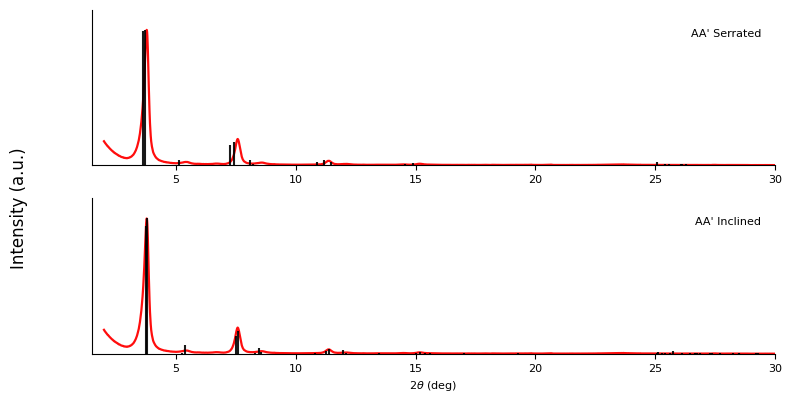

'ILCOF-1/5_ILCOF-1_analysis/ILCOF-1_both.png'

In [12]:
pxrd = cl.Pxrd()
pxrd.plot_sim_vs_exp(
    cof_name=COF_NAME,
    mode=MODE,
    simulated_xy_folder=f"{COF_NAME}/5_{COF_NAME}_analysis/pxrd_xy_paper",  
    xlim=(1.5, 30.0),
    show=True,
    save=True,
)

In [ ]:
pxrd = cl.Pxrd()
pxrd.plot_sim(
    cof_name=COF_NAME,
    mode=MODE,
    dft=False,
    xy_folder=f"{COF_NAME}/5_{COF_NAME}_analysis/pxrd_xy",
    output_folder=f"{COF_NAME}/5_{COF_NAME}_analysis",
    xlim=(1.5, 60.0),
    show=True,
    save=True,
)